<a href="https://colab.research.google.com/github/actelleza-maker/Ciencia-de-datos-con-IA/blob/main/Copia_de_Proyecto_Introducci%C3%B3n_al_An%C3%A1lisis_Estad%C3%ADstico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROYECTO: INTRODUCCIÓN AL ANÁLISIS ESTADÍSTICO**

Una vez visto el ***Módulo 2: Fundamentos Estadísticos***, se presenta la siguiente actividad para que el alumnado pueda poner a prueba lo aprendido durante este módulo.

Dentro de la siguiente dinámica, realizar el siguiente **análisis exploratorio con aprendizaje estadístico** de cualquier dataset proveniente de la librería de ***Seaborn*** que no haya sido utilizado.

Se sugiere los siguientes puntos para llevar a cabo lo anterior:

*   Realizar un **análisis descriptivo** para comprender comportamiento de la descripción de los datos a través de resúmenes.
*   Realizar un **aprendizaje estadístico** para predecir comportamientos lineales de datos a través de la regresión lineal simple.

In [28]:
# Importar librerías

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Importar dataset

df_diamonds = sns.load_dataset('diamonds')
df_diamonds


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [4]:
# Mostrar propiedades de la tabla
df_diamonds.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [6]:
# Mostrar resumen estadístico

df_diamonds.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


# **Medidas de tendencia central**

In [8]:
# Definir variables (referentes al precio)

media = round(df_diamonds['price'].mean(), 2)
mediana = round(df_diamonds['price'].median(), 2)
moda = round(df_diamonds['price'].mode().iloc[0], 2)

print(f'Las MTC son : media {media}, mediana {mediana} y moda {moda}')

Las MTC son : media 3932.8, mediana 2401.0 y moda 605


In [9]:
# Definir listas

mtc_datos = [moda, mediana, media]
mtc_nombres = ['Moda', 'Mediana', 'Media']
mtc_colores = ['green', 'red', 'blue']

mtc_configuraciones = zip(mtc_datos, mtc_nombres, mtc_colores)

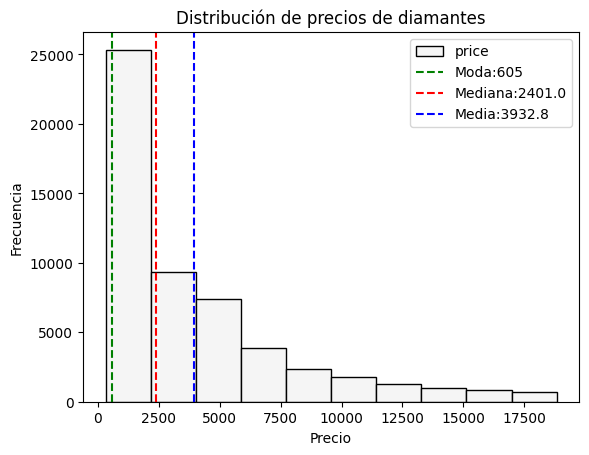

In [11]:
# Visualizar métricas de tendencia central

df_diamonds['price'].plot(kind = 'hist', edgecolor = 'black', color = 'whitesmoke')
plt.title('Distribución de precios de diamantes')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')

for dato, nombre, color in mtc_configuraciones:
    plt.axvline(x = dato, color = color, linestyle = '--', label =f'{nombre}:{dato}')

plt.legend()

# **Medidas de dispersión**

Desviación Estándar

In [12]:
# Definir variables

x = range(len(df_diamonds['price']))
y = df_diamonds['price']

std = np.std(y)

In [16]:
# Definir listas

std_datos = [media, media + std, media - std]
std_nombre = ['Media', 'desviación estándar', None]
std_color = ['red', 'blue', 'blue']

std_configuraciones = zip(std_datos, std_nombre, std_color)

std_datos

[np.float64(3932.8),
 np.float64(7922.202757628797),
 np.float64(-56.60275762879701)]

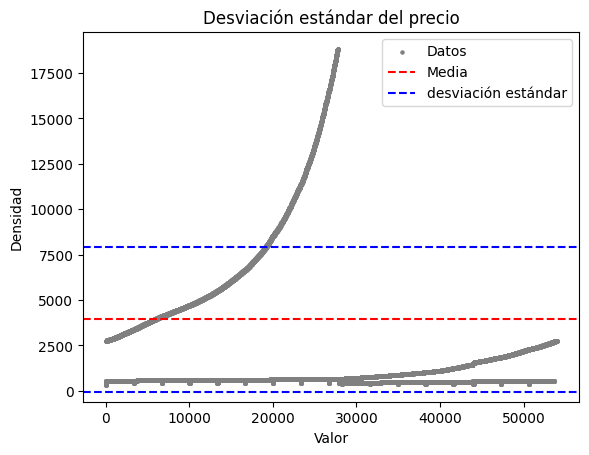

In [17]:
from matplotlib import lines
from matplotlib.lines import lineStyles

# Visualizar dipersión de los datos
plt.scatter(x, y, label = 'Datos', s = 5, color = 'gray')
plt.title('Desviación estándar del precio')
plt.xlabel('Valor')
plt.ylabel('Densidad')

for dato, nombre, color in std_configuraciones:
    plt.axhline(y = dato, c = color, linestyle = '--', label = nombre)

plt.legend()

Percentiles

In [18]:
# Definir variables

percentil = np.percentile(df_diamonds['price'], [25,50,75])
q1=round(percentil[0],2)
q3=round(percentil[2],2)

iqr = q3 -q1

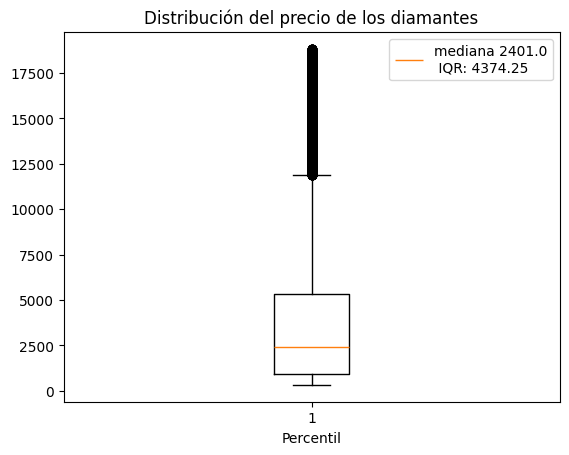

In [19]:
# Visualizar percentiles

plt.boxplot(df_diamonds['price'], label = f'mediana {mediana}\n IQR: {iqr}')
plt.title('Distribución del precio de los diamantes')
plt.xlabel('Precio del diamante')
plt.xlabel('Percentil')
plt.legend()
plt.show()

Text(0.5, 0, 'Precio del diamante')

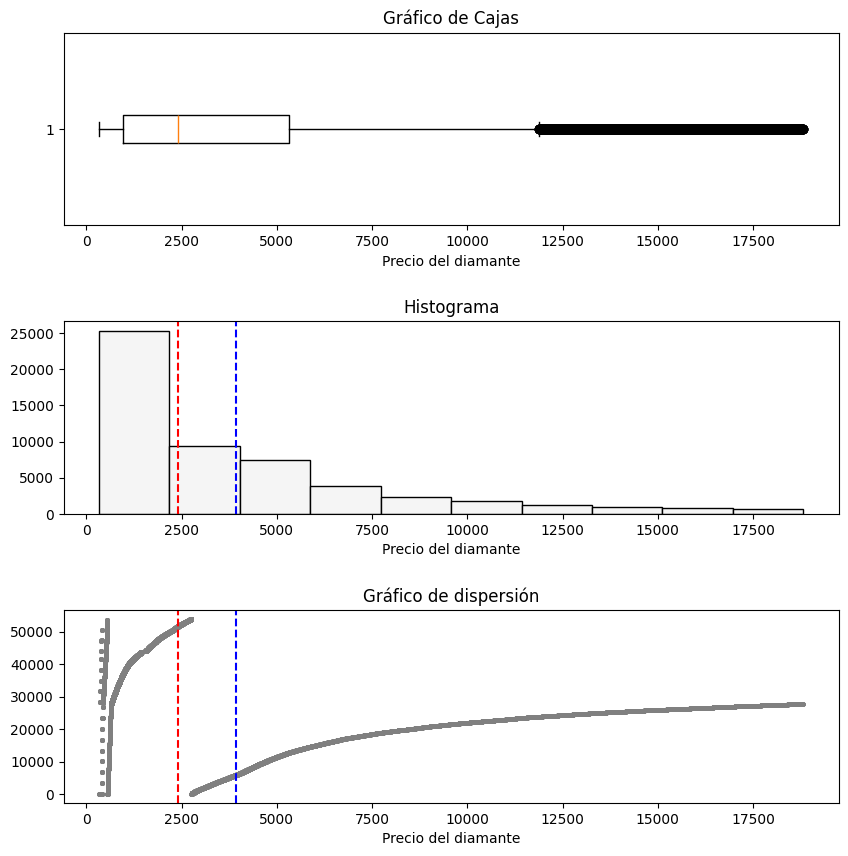

In [21]:
# Asociar gráficos
fig, ax = plt.subplots(3, figsize = (10, 10), gridspec_kw={'hspace': 0.5})

#Gráficode cajas
ax[0].boxplot (df_diamonds['price'], vert = False)
ax[0].set_title('Gráfico de Cajas')
ax[0].set_xlabel('Precio del diamante')

#Histograma con HTC
ax[1].hist (df_diamonds['price'], edgecolor = 'black', color = 'whitesmoke')
ax[1].axvline(x = mediana, color = 'red', linestyle = '--')
ax[1].axvline(x = media, color = 'blue', linestyle = '--')
ax[1].set_title('Histograma')
ax[1].set_xlabel('Precio del diamante')

#Gráfica de dispersión
ax[2].scatter (y, x, s= 5, color = 'gray')
ax[2].axvline(x = mediana, color = 'red', linestyle = '--')
ax[2].axvline(x = media, color = 'blue', linestyle = '--')
ax[2].set_title('Gráfico de dispersión')
ax[2].set_xlabel('Precio del diamante')

# **ANALISIS MULTIVARIABLE**

Correlación

In [22]:
# Definir variables

columnas = ['carat', 'depth', 'table', 'price']
corr = df_diamonds[columnas].corr()
long_col = len(columnas)

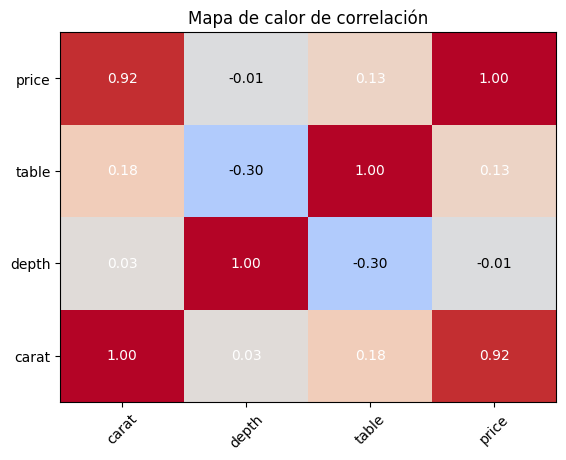

In [23]:
# Visualizar mapa de calor

heatmap = plt.pcolor(corr, cmap = 'coolwarm', vmin = -1, vmax = 1)
plt.title('Mapa de calor de correlación')
plt.xticks(np.arange(0.5, long_col, 1), columnas, rotation = 45)
plt.yticks(np.arange(0.5, long_col, 1), columnas)

for i in range(long_col):
    for j in range(long_col):
        plt.text(j+0.5, i+0.5, f'{corr.iloc[i,j]:0.2f}',
          ha = 'center', va = 'center',
          color = 'white' if corr.iloc[i,j] > 0 else 'black')

# **Bivariable**

In [24]:
# Definir variables

corr_carat_precio = round(df_diamonds['price'].corr(df_diamonds['carat']),2)


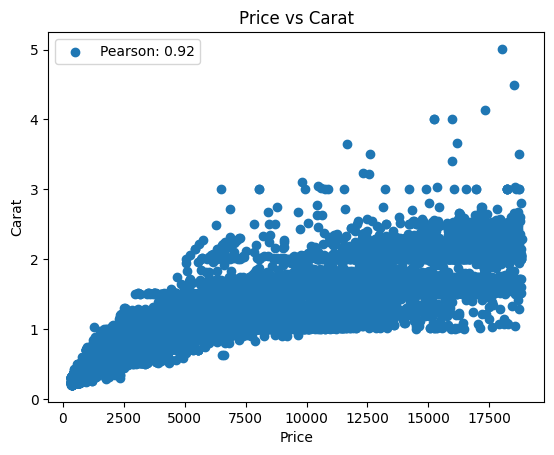

In [27]:
# Visualizar correlaciones

plt.scatter(data = df_diamonds, x = 'price', y = 'carat', label = f'Pearson: {corr_carat_precio}')
plt.title('Price vs Carat')
plt.xlabel('Price')
plt.ylabel('Carat')
plt.legend()
plt.show()

# **Estadística inferencial**

**Prueba de hipótesis**

In [29]:
# Importar módulo

from scipy import stats

**Caso práctico:** ¿Existe una diferencia significativa entre el precio de un diamante con con corte ideal y un corte premium?

*   **H0:** La media de precio es igual para ambos grupos.

*  **H1:** La media de precio es distinta entre diamantes con un corte ideal y un corte premium.






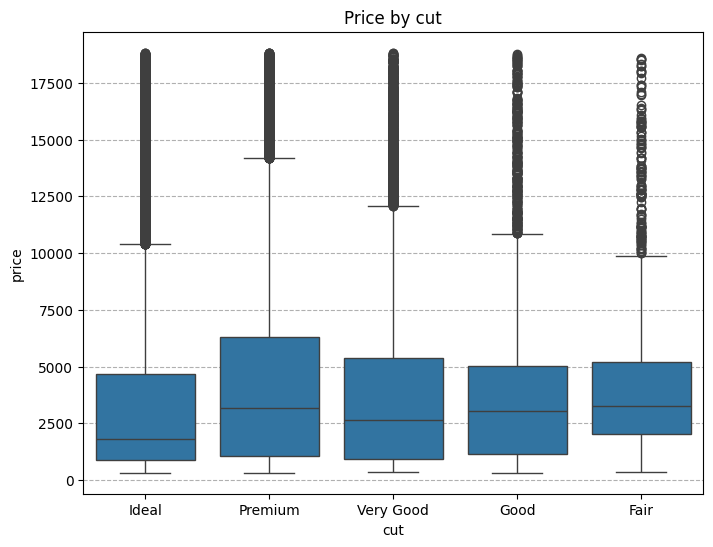

In [32]:

plt.figure(figsize=(8, 6))
sns.boxplot(x='cut', y='price', data=df_diamonds)
plt.title('Price by cut')
plt.xlabel('cut')
plt.ylabel('price')
plt.grid(axis='y', linestyle='--')
plt.show()


In [41]:
# Separaración de grupos

precio_ideal = df_diamonds[df_diamonds['cut'] == 'Ideal']['price']
precio_premium = df_diamonds[df_diamonds['cut'] == 'Premium']['price']


In [42]:
# Aplicar Prueba T de Student

t_stat, p_value = stats.ttest_ind(precio_ideal, precio_premium)

print("Estadístico t:", t_stat)
print("Valor p:", p_value)

Estadístico t: -25.650910588183198
Valor p: 8.585274269295433e-144


In [43]:
# Interpretar resultados

def interpretar_pvalue(p_value):
    if p_value < 0.01:
      print("\nConclusión: Rechazamos la Hipótesis Nula.")
      print("Existe una diferencia muy significativa entre tus muestras")
    elif p_value>=0.01 and p_value < 0.05:
      print("\nConclusión: Rechazamos la Hipótesis Nula.")
      print("Existe una diferencia altamente significativa entre tus muestras")
    elif p_value>=0.05 and p_value < 0.10:
      print("\nConclusión: Rechazamos la Hipótesis Nula.")
      print("Existe una diferencia moderadamente significativa entre tus muestras")
    else:
      print("\nConclusión: No podemos rechazar la Hipótesis Nula.")
      print("No hay evidencia suficiente para concluir que las medias son diferentes")

In [37]:
interpretar_pvalue(p_value)


Conclusión: Rechazamos la Hipótesis Nula.
Existe una diferencia muy significativa entre tus muestras


# **Aprendizaje estadístico**

**Regresión lineal simple**

Se analiza la relación entre la longitud del diamante en mm y su profundidad en mm

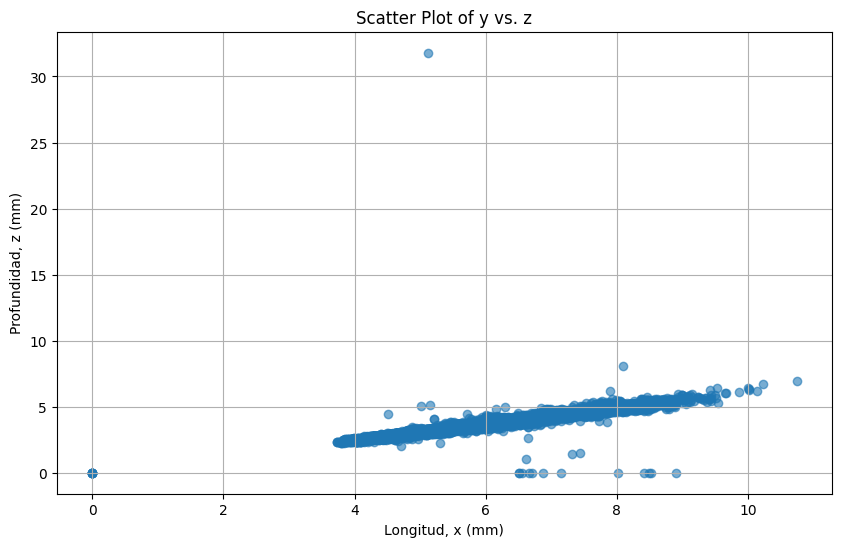

In [46]:
x = df_diamonds['x']
y = df_diamonds['z']


plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6)
plt.title('Scatter Plot of y vs. z')
plt.xlabel('Longitud, x (mm)')
plt.ylabel('Profundidad, z (mm)')
plt.grid(True)
plt.show()

In [47]:
# Definir regresión lineal

linear_regression = np.polyfit(x, y, 1)
beta, alpha = linear_regression

print(f'y = {beta} x + {alpha}')

y = 0.610711812538056 x + 0.03864836956408452


In [49]:
# Predicción de valores con regresión lineal

tb_pred_lr = int(input('Agrega el valor de la longitud del diamante en mm para predecir su profundidad:'))
y_pred_lr = round(beta * tb_pred_lr + alpha, 2)

print(f'La profundidad será de {y_pred_lr}')

Agrega el valor de la longitud del diamante en mm para predecir su profundidad:4
La profundidad será de 2.48


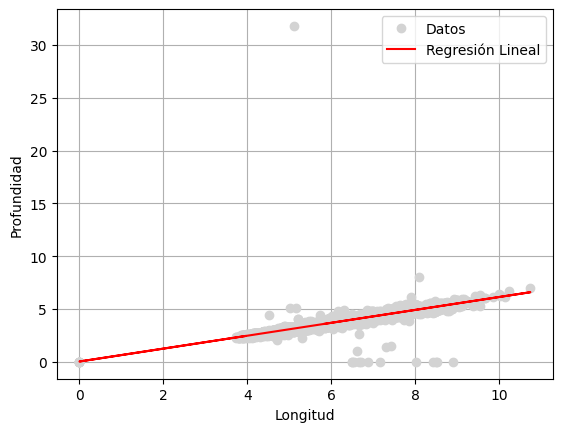

In [50]:
# Visualizar regresión lineal

plt.plot(x,y, 'o', color = 'lightgray', label = 'Datos')
plt.plot(x, beta * x + alpha, 'r', label = 'Regresión Lineal')
plt.xlabel('Longitud')
plt.ylabel('Profundidad')
plt.legend()
plt.grid()
plt.show()

**Error cuadrático medio**

In [51]:
y_pred_err = np.polyval(linear_regression, x)
error = ((y-y_pred_err) **2).mean()

print(f'El error cuadrático medio es: {error}')

El error cuadrático medio es: 0.028685947199121358


**Función de pérdida**

In [53]:
# Iterar pérdida de la regresión lineal

num_iteraciones = 100
perdida =[]

for i in range(num_iteraciones):
  y_pred = np.polyval(linear_regression, x)
  error = ((y-y_pred) **2).mean()
  perdida.append(error)

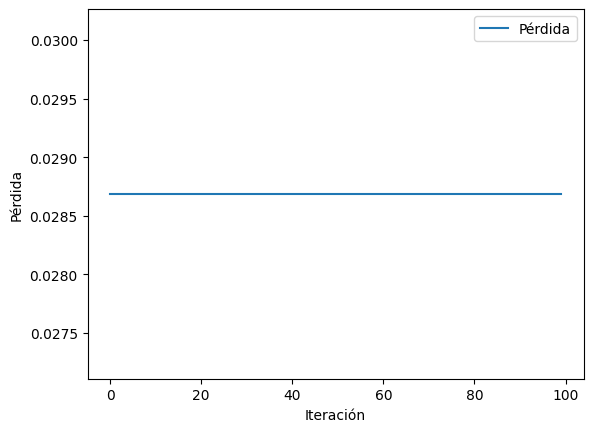

In [54]:
# Visualizar pérdida de la regresión lineal

plt.plot(perdida, label='Pérdida')
plt.xlabel('Iteración')
plt.ylabel('Pérdida')
plt.legend()


**Descenso de gradiente**

In [55]:
# Definir parámetros

tamaño_paso = 0.001 #Alpha
theta_0 = 0.1
theta_1 = 0.1

perdida = []


In [56]:
n = len(df_diamonds['x'])
print(n)

53940


In [57]:
# Realizar algoritmo del descenso de gradiente

num_iteraciones = 100

for i in range(num_iteraciones):
  y_pred = theta_1 * x + theta_0
  error = ((y_pred - y)**2).mean()
  perdida.append(error)

  d_theta_0 = (2 /n) * np.sum(y_pred - y)
  d_theta_1 = (2 /n) * np.sum((y_pred - y) * x)

  theta_0 = theta_0 - (tamaño_paso * d_theta_0)
  theta_1 = theta_1 - (tamaño_paso * d_theta_1)

print(f'y = {theta_1} x + {theta_0}')

y = 0.5864541369429972 x + 0.1807801785193851


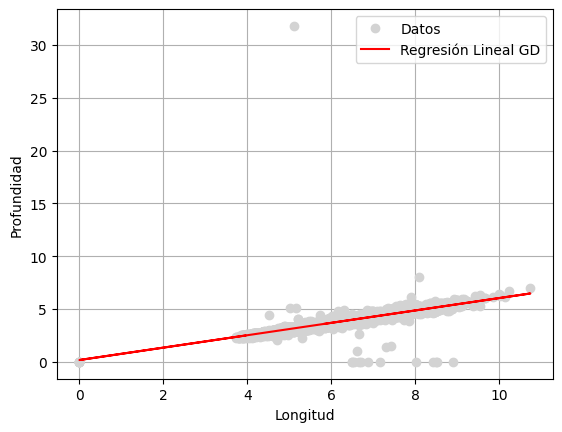

In [58]:
# Visualizar la regresión lineal por descenso de gradiente

plt.plot(x,y, 'o', color = 'lightgray', label = 'Datos')
plt.plot(x, theta_1 * x + theta_0, color = 'red', label = 'Regresión Lineal GD')
plt.xlabel('Longitud')
plt.ylabel('Profundidad')
plt.legend()
plt.grid()
plt.show()

In [59]:
# Predicción de valores con descenso de gradiente

tb_pred_gd = int(input('Agrega el valor de la longitud del diamante en mm para predecir su profundidad:'))
y_pred_gd = round(theta_1 * tb_pred_gd + theta_0, 2)

print(f'La profundidad será de {y_pred_gd}')

Agrega el valor de la longitud del diamante en mm para predecir su profundidad:4
La profundidad será de 2.53


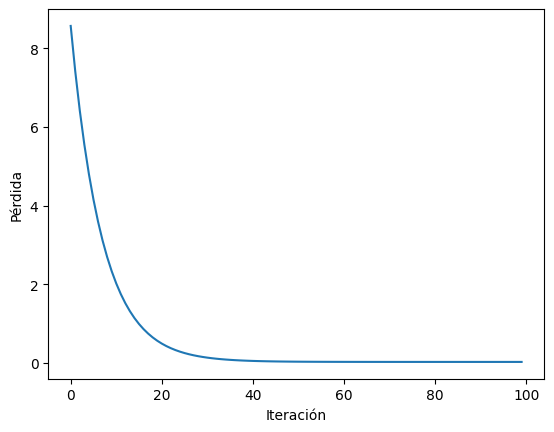

In [60]:
# Visualizar las pérdidas

plt.plot(perdida)
plt.xlabel('Iteración')
plt.ylabel('Pérdida')
plt.show()

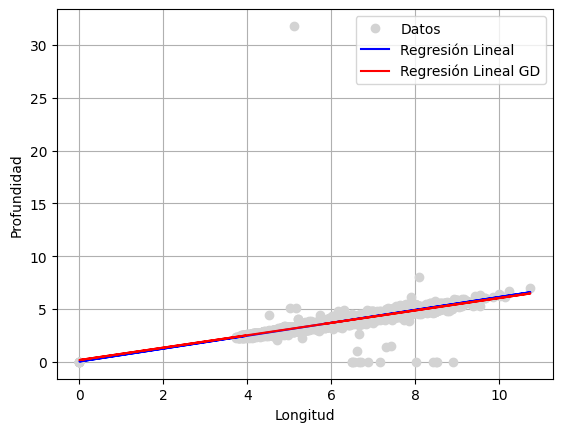

In [62]:
# Comparar las rectas obtenidas por los algoritmos

plt.plot(x, y, 'o', color = 'lightgray', label = 'Datos')
plt.plot(x, beta * x + alpha, color = 'blue', label = 'Regresión Lineal')
plt.plot(x, theta_1 * x + theta_0, color= 'red', label = 'Regresión Lineal GD')
plt.xlabel('Longitud')
plt.ylabel('Profundidad')
plt.legend()
plt.grid()
plt.show()